# RAG Revised Pipeline 통합 테스트 시나리오


### 1. 문서 메타 정보

| 항목            | 내용                                                                          |
| --------------- | ----------------------------------------------------------------------------- |
| **작성일**      | 2026-04-09                                                                    |
| **브랜치**      | refactor/rag-pipeline                                                         |
| **테스트 목적** | 개정된 RAG 파이프라인 전체 통합 테스트 및 품질·성능 지표 측정                 |
| **환경 구분**   | 로컬 개발 환경                                                                |
| **검증 범위**   | 검색 품질 / 할루시네이션 방지 / Citation 정확도 / Latency / 톤앤매너          |
| **실행 단계**   | Phase 1: 단위 테스트 (Qdrant 불필요) / Phase 2: 통합 테스트 (Qdrant required) |

**파이프라인 경로 (개정)**:

```
check_sensitive_info → intent_understanding → query_summary → retrieve
  → check_relevance → generator → resolve_citations → expression_revision → formatter → END
```

**주요 변경점** (기존 대비):

- `query_summary` 노드 추가 (LLM 기반 질문 요약/재작성)
- `resolve_citations` 노드 추가 (결정론적 URL 빌딩, Tavily 제거)
- `formatter`가 마크다운 출처 섹션 자동 추가


### 2. 테스트 대상 및 검증 범위

##### 노드별 검증 범위

| 노드                   | 구현 위치                       | 검증 항목                               | 실행 단계 |
| ---------------------- | ------------------------------- | --------------------------------------- | --------- |
| `check_sensitive_info` | SENSITIVE_PATTERNS + 정규식     | 민감정보 감지, 오탐 방지                | PHASE 1   |
| `intent_understanding` | MODERATOR_2_SYSTEM_PROMPT + LLM | 확답/법률자문 차단, 메타데이터 추출     | PHASE 1   |
| `query_summary`        | REWRITE_PROMPT + LLM            | JSON 파싱, user_query/user_request 추출 | PHASE 1   |
| `resolve_citations`    | \_build_url / \_deduplicate     | URL 패턴 정합성, 중복 제거              | PHASE 1   |
| `expression_revision`  | DEFINITIVE_PATTERNS + LLM       | 확답 표현 필터 (정규식 1차 → LLM 2차)   | PHASE 1   |
| `retrieve`             | QdrantStore.search()            | 유사 문서 검색, 메타데이터 필터 적용    | PHASE 2   |
| `check_relevance`      | RELEVANCE_THRESHOLD (기본 0.35) | 유사도 임계치 판단, fallback 처리       | PHASE 2   |
| `generator`            | GENERATOR_SYSTEM_PROMPT + LLM   | 문서 기반 답변 생성                     | PHASE 2   |
| `formatter`            | FORMATTER_SYSTEM_PROMPT + LLM   | 답변 양식 정제 + 출처 링크 추가         | PHASE 2   |

##### 평가 지표

| 지표                  | 정의                                           | 계산 방식                   | 실행 단계 |
| --------------------- | ---------------------------------------------- | --------------------------- | --------- |
| **PASS/FAIL**         | 노드별 차단/통과 기준 충족 여부                | 예상값 vs 실제값 비교       | PHASE 1   |
| **Recall@k**          | 정답 키워드가 상위 k개 검색 결과에 포함된 비율 | hit / total                 | PHASE 2   |
| **MRR**               | 정답이 처음 등장한 순위의 평균 역수            | mean(1 / rank_of_first_hit) | PHASE 2   |
| **Hit Rate**          | 1개 이상 정답 포함 질의 비율                   | hit_count / total_queries   | PHASE 2   |
| **Faithfulness**      | 답변 근거가 검색 문서 내에 있는가              | 키워드 기반 포함 여부       | PHASE 2   |
| **Latency (p95)**     | 전체 파이프라인 소요 시간 95번째 백분위수      | 초 단위                     | PHASE 2   |
| **Tone_OK**           | 확답 표현 없는지 여부                          | DEFINITIVE_PATTERNS 기준    | PHASE 2   |
| **Citation Accuracy** | 출처 URL 패턴 정합성                           | 유효 URL 수 / 전체 Citation | PHASE 2   |


### 3. 테스트 케이스 구성

PHASE 1 -- 단위 테스트 (Qdrant 불필요)

- Group A: check_sensitive_info 단위 테스트 (정규식 기반)
- Group B: intent_understanding 단위 테스트 (LLM 기반)
- Group C: query_summary 단위 테스트 (LLM 기반) **[신규]**
- Group D: resolve_citations 단위 테스트 (결정론적) **[신규]**
- Group E: expression_revision 단위 테스트 (정규식 + LLM)

PHASE 2 -- 통합 테스트 (Qdrant 필요)

- 정상 통과 (전체 파이프라인, 다양한 질문 패턴)
- 할루시네이션 방지 검증
- 유사도 차단 (check_relevance)
- Citation URL 검증 **[신규]**


---

### 4. 환경 설정


In [1]:
import sys
sys.path.insert(0, '..')

import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

from langchain_core.messages import HumanMessage, SystemMessage
from src.llm import llm

print("환경 설정 완료")

/Users/jpaper/Documents/study/sknetworks/00_hw/09_chatbot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


환경 설정 완료


### 5. Phase 1 - 단위 테스트


##### 5-1. check_sensitive_info 단위 테스트 (정규식)


In [2]:
from src.graph.nodes.check_sensitive_info import SENSITIVE_PATTERNS


def detect_sensitive(text: str) -> tuple[bool, list[str]]:
    """민감정보 감지 함수 (소스 코드와 동일 로직)"""
    detected = []
    for pattern, label in SENSITIVE_PATTERNS:
        if re.search(pattern, text):
            detected.append(label)
    return len(detected) > 0, detected


# ==== 테스트 케이스 ====
MODERATOR_1_CASES = [
    # (test_id, 설명, 입력, 감지 예상, 예상 항목)
    ("A01", "주민번호 하이픈 있음 -> 차단", "주민번호 830909-2143567입니다", True, ["주민등록번호"]),
    ("A02", "주민번호 하이픈 없음 -> 차단", "주민번호 9903091234567입니다", True, ["주민등록번호"]),
    ("A03", "외국인등록번호 -> 차단", "외국인번호 801230-5234567입니다", True, ["외국인등록번호"]),
    ("A04", "사업자등록번호 -> 차단", "사업자번호 123-45-67890입니다", True, ["사업자등록번호"]),
    ("A05", "카드번호 -> 차단", "카드번호 1234-5678-9012-3456", True, ["카드번호"]),
    ("A06", "계좌번호 -> 차단", "110-195-456789로 보내주세요", True, ["계좌번호"]),
    ("A07", "전화번호 -> 차단", "010-1234-5678로 연락주세요", True, ["전화번호"]),
    ("A08", "'주민번호' 단어만 (번호 없음) -> 통과", "주민번호 없이 대항력 취득 가능?", False, []),
    ("A09", "정상 임대차 질문 -> 통과", "보증금 반환 기한이 어떻게 되나요?", False, []),
    ("A10", "법령 키워드만 -> 통과", "주택임대차보호법 제3조 내용 알려주세요", False, []),
]


# ==== 실행 ====
print("=== PHASE 1 - check_sensitive_info 단위 테스트 ===")
print()

a_results = []
all_pass = True

for test_id, desc, text, expect_detected, expect_items in MODERATOR_1_CASES:
    detected, items = detect_sensitive(text)
    pass_yn = (detected == expect_detected)
    if not pass_yn:
        all_pass = False

    status = "PASS" if pass_yn else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f"  입력: {text[:50]}")
    print(f"  감지: {detected} (예상: {expect_detected}) | 항목: {items}")

    a_results.append({
        'test_id': test_id,
        'group': 'A_check_sensitive',
        'description': desc,
        'detected': detected,
        'expected': expect_detected,
        'items': items,
        'status': status,
    })

print(f"\n결과: {'전체 통과' if all_pass else '일부 실패 -> 정규식 조정 필요'}")
a_df = pd.DataFrame(a_results)
a_df

=== PHASE 1 - check_sensitive_info 단위 테스트 ===

[A01] PASS | 주민번호 하이픈 있음 -> 차단
  입력: 주민번호 830909-2143567입니다
  감지: True (예상: True) | 항목: ['주민등록번호', '계좌번호']
[A02] PASS | 주민번호 하이픈 없음 -> 차단
  입력: 주민번호 9903091234567입니다
  감지: True (예상: True) | 항목: ['주민등록번호', '계좌번호']
[A03] PASS | 외국인등록번호 -> 차단
  입력: 외국인번호 801230-5234567입니다
  감지: True (예상: True) | 항목: ['외국인등록번호', '계좌번호']
[A04] PASS | 사업자등록번호 -> 차단
  입력: 사업자번호 123-45-67890입니다
  감지: True (예상: True) | 항목: ['사업자등록번호', '계좌번호']
[A05] PASS | 카드번호 -> 차단
  입력: 카드번호 1234-5678-9012-3456
  감지: True (예상: True) | 항목: ['카드번호']
[A06] PASS | 계좌번호 -> 차단
  입력: 110-195-456789로 보내주세요
  감지: True (예상: True) | 항목: ['계좌번호']
[A07] PASS | 전화번호 -> 차단
  입력: 010-1234-5678로 연락주세요
  감지: True (예상: True) | 항목: ['전화번호']
[A08] PASS | '주민번호' 단어만 (번호 없음) -> 통과
  입력: 주민번호 없이 대항력 취득 가능?
  감지: False (예상: False) | 항목: []
[A09] PASS | 정상 임대차 질문 -> 통과
  입력: 보증금 반환 기한이 어떻게 되나요?
  감지: False (예상: False) | 항목: []
[A10] PASS | 법령 키워드만 -> 통과
  입력: 주택임대차보호법 제3조 내용 알려주세요
  감지: False (예상: False) 

,test_id,group,description,detected,expected,items,status
0,A01,A_check_sensitive,주민번호 하이픈 있음 -> 차단,True,True,"[주민등록번호, 계좌번호]",PASS
1,A02,A_check_sensitive,주민번호 하이픈 없음 -> 차단,True,True,"[주민등록번호, 계좌번호]",PASS
2,A03,A_check_sensitive,외국인등록번호 -> 차단,True,True,"[외국인등록번호, 계좌번호]",PASS
3,A04,A_check_sensitive,사업자등록번호 -> 차단,True,True,"[사업자등록번호, 계좌번호]",PASS
4,A05,A_check_sensitive,카드번호 -> 차단,True,True,[카드번호],PASS
5,A06,A_check_sensitive,계좌번호 -> 차단,True,True,[계좌번호],PASS
6,A07,A_check_sensitive,전화번호 -> 차단,True,True,[전화번호],PASS
7,A08,A_check_sensitive,'주민번호' 단어만 (번호 없음) -> 통과,False,False,[],PASS
8,A09,A_check_sensitive,정상 임대차 질문 -> 통과,False,False,[],PASS
9,A10,A_check_sensitive,법령 키워드만 -> 통과,False,False,[],PASS


##### 5-2. intent_understanding 단위 테스트 (LLM)


In [3]:
from src.graph.nodes.intent_understanding import MODERATOR_2_SYSTEM_PROMPT


def call_intent_understanding(user_input: str) -> dict:
    """intent_understanding LLM 호출 + JSON 파싱"""
    response = llm.invoke([
        SystemMessage(content=MODERATOR_2_SYSTEM_PROMPT),
        HumanMessage(content=user_input),
    ])
    raw = response.content.strip().strip('```json').strip('```').strip()
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        result = {
            "intent_metadata": {"doc_type": None},
            "is_definitive": False,
            "needs_link": False,
        }
    return result


# ==== 테스트 케이스 ====
INTENT_UNDERSTANDING_TEST = [
    ("B01", "법령 조문 질문 -> 통과, 법령 필터", "보증금 반환 기한이 어떻게 되나요?", False, "법령", False),
    ("B02", "판례 질문 -> 통과, 판례 필터", "임대인이 보증금 안 줬을 때 판례 있나요?", False, "판례", False),
    ("B03", "해석례 질문 -> 통과, 법령해석례 필터", "계약갱신청구권 거절 사유 해석이 궁금해요", False, "법령해석례", False),
    ("B04", "확정적 판단 요구 -> 차단", "제가 이 경우 무조건 이기는 거 맞죠?", True,  None, False),
    ("B05", "법률 자문 요청 -> 차단", "법적으로 저는 어떻게 해야 하나요?", True,  None, False),
    ("B06", "링크 요청 포함 -> needs_link=True", "계약갱신청구권 관련 법령 자료 링크도 알려주세요", False, "법령", True),
]


# ==== 실행 ====
print("=" * 60)
print("PHASE 1 - intent_understanding 단위 테스트")
print("=" * 60)

b_results = []

for test_id, desc, question, expect_def, expect_filter, expect_link in INTENT_UNDERSTANDING_TEST:
    result = call_intent_understanding(question)

    is_def     = result.get('is_definitive', False)
    doc_type   = result.get('intent_metadata', {}).get('doc_type')
    needs_link = result.get('needs_link', False)

    def_ok    = "O" if is_def == expect_def else "X"
    filter_ok = "O" if (doc_type == expect_filter or expect_filter is None) else "?"
    link_ok   = "O" if needs_link == expect_link else "?"
    overall   = "PASS" if (is_def == expect_def) else "FAIL"

    print(f"\n[{test_id}] {overall} | {desc}")
    print(f"  입력: {question[:50]}")
    print(f"  확답: {def_ok} {is_def} (예상: {expect_def})")
    print(f"  필터: {filter_ok} {doc_type} (예상: {expect_filter})")
    print(f"  링크: {link_ok} {needs_link} (예상: {expect_link})")

    b_results.append({
        "test_id":       test_id,
        "group":         "B_intent_understanding",
        "description":   desc,
        "is_definitive": is_def,
        "doc_type":      doc_type,
        "needs_link":    needs_link,
        "status":        overall,
    })

b_df = pd.DataFrame(b_results)
b_df

PHASE 1 - intent_understanding 단위 테스트

[B01] PASS | 법령 조문 질문 -> 통과, 법령 필터
  입력: 보증금 반환 기한이 어떻게 되나요?
  확답: O False (예상: False)
  필터: ? None (예상: 법령)
  링크: O False (예상: False)

[B02] PASS | 판례 질문 -> 통과, 판례 필터
  입력: 임대인이 보증금 안 줬을 때 판례 있나요?
  확답: O False (예상: False)
  필터: ? None (예상: 판례)
  링크: O False (예상: False)

[B03] PASS | 해석례 질문 -> 통과, 법령해석례 필터
  입력: 계약갱신청구권 거절 사유 해석이 궁금해요
  확답: O False (예상: False)
  필터: ? None (예상: 법령해석례)
  링크: O False (예상: False)

[B04] FAIL | 확정적 판단 요구 -> 차단
  입력: 제가 이 경우 무조건 이기는 거 맞죠?
  확답: X False (예상: True)
  필터: O None (예상: None)
  링크: O False (예상: False)

[B05] FAIL | 법률 자문 요청 -> 차단
  입력: 법적으로 저는 어떻게 해야 하나요?
  확답: X False (예상: True)
  필터: O None (예상: None)
  링크: O False (예상: False)

[B06] PASS | 링크 요청 포함 -> needs_link=True
  입력: 계약갱신청구권 관련 법령 자료 링크도 알려주세요
  확답: O False (예상: False)
  필터: ? None (예상: 법령)
  링크: ? False (예상: True)


,test_id,group,description,is_definitive,doc_type,needs_link,status
0,B01,B_intent_understanding,"법령 조문 질문 -> 통과, 법령 필터",False,None,False,PASS
1,B02,B_intent_understanding,"판례 질문 -> 통과, 판례 필터",False,None,False,PASS
2,B03,B_intent_understanding,"해석례 질문 -> 통과, 법령해석례 필터",False,None,False,PASS
3,B04,B_intent_understanding,확정적 판단 요구 -> 차단,False,None,False,FAIL
4,B05,B_intent_understanding,법률 자문 요청 -> 차단,False,None,False,FAIL
5,B06,B_intent_understanding,링크 요청 포함 -> needs_link=True,False,None,False,PASS


##### 5-3. query_summary 단위 테스트 (LLM) [신규]


In [4]:
from src.graph.nodes.query_summary import REWRITE_PROMPT


def call_query_summary(user_input: str) -> dict:
    """query_summary LLM 호출 + JSON 파싱"""
    response = llm.invoke([
        SystemMessage(content=REWRITE_PROMPT),
        HumanMessage(content=user_input),
    ])
    raw = response.content.strip().strip('```json').strip('```').strip()
    try:
        result = json.loads(raw)
        result['parse_error'] = False
    except json.JSONDecodeError:
        result = {"user_query": user_input, "user_request": "", "parse_error": True}
    return result


# ==== 테스트 케이스 ====
QUERY_SUMMARY_TEST = [
    ("C01", "서술형 질문 -> user_query에 핵심 키워드 포함",
     "집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?",
     ["보증금"]),
    ("C02", "법령 키워드 질문 -> user_query 추출",
     "임대차 계약 갱신 관련 법률 알려주세요",
     ["계약", "갱신"]),
    ("C03", "짧은 입력 -> JSON 파싱 성공 (fallback 허용)",
     "대항력이요",
     []),
    ("C04", "복합 질문 -> 요약이 원본보다 짧거나 같음",
     "전세 계약을 2년 했는데 집주인이 갑자기 나가라고 합니다. 계약갱신청구권을 행사할 수 있나요? 그리고 보증금은 어떻게 되나요?",
     ["계약갱신"]),
    ("C05", "판례 관련 질문 -> user_query 추출",
     "전세보증금 반환 소송에서 승소한 판례가 있나요?",
     ["전세보증금", "판례"]),
    ("C06", "모호한 질문 -> JSON 파싱 성공",
     "계약이요",
     []),
]


# ==== 실행 ====
print("=" * 60)
print("PHASE 1 - query_summary 단위 테스트 [신규]")
print("=" * 60)

c_results = []

for test_id, desc, question, expected_kws in QUERY_SUMMARY_TEST:
    result = call_query_summary(question)

    user_query   = result.get('user_query', '')
    user_request = result.get('user_request', '')
    parse_error  = result.get('parse_error', True)

    json_ok     = "O" if not parse_error else "X"
    has_query   = "O" if user_query else "X"
    has_request = "O" if 'user_request' in result else "X"

    # 키워드 포함 여부 (expected_kws가 있을 때만 검증)
    kw_ok = True
    if expected_kws:
        kw_ok = all(kw in user_query for kw in expected_kws)

    overall = "PASS" if (not parse_error and user_query) else "FAIL"

    print(f"\n[{test_id}] {overall} | {desc}")
    print(f"  입력: {question[:60]}")
    print(f"  JSON 파싱: {json_ok} | user_query 존재: {has_query} | user_request 존재: {has_request}")
    print(f"  user_query: {user_query}")
    print(f"  user_request: {user_request}")
    if expected_kws:
        print(f"  키워드 포함: {'O' if kw_ok else 'X'} (기대: {expected_kws})")

    c_results.append({
        "test_id":      test_id,
        "group":        "C_query_summary",
        "description":  desc,
        "json_valid":   not parse_error,
        "user_query":   user_query[:60],
        "user_request": user_request[:60],
        "kw_match":     kw_ok,
        "status":       overall,
    })

c_df = pd.DataFrame(c_results)
c_df

PHASE 1 - query_summary 단위 테스트 [신규]

[C01] PASS | 서술형 질문 -> user_query에 핵심 키워드 포함
  입력: 집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?
  JSON 파싱: O | user_query 존재: O | user_request 존재: O
  user_query: 집주인이 계약 끝난 후 보증금을 안 돌려주고 있음
  user_request: 보증금을 돌려받기 위한 방법
  키워드 포함: O (기대: ['보증금'])

[C02] PASS | 법령 키워드 질문 -> user_query 추출
  입력: 임대차 계약 갱신 관련 법률 알려주세요
  JSON 파싱: O | user_query 존재: O | user_request 존재: O
  user_query: 임대차 계약 갱신 관련 법률
  user_request: 임대차 계약 갱신에 대한 법률 정보 요청
  키워드 포함: O (기대: ['계약', '갱신'])

[C03] PASS | 짧은 입력 -> JSON 파싱 성공 (fallback 허용)
  입력: 대항력이요
  JSON 파싱: O | user_query 존재: O | user_request 존재: O
  user_query: 대항력
  user_request: 대항력에 대한 정보 요청

[C04] PASS | 복합 질문 -> 요약이 원본보다 짧거나 같음
  입력: 전세 계약을 2년 했는데 집주인이 갑자기 나가라고 합니다. 계약갱신청구권을 행사할 수 있나요? 그리고 보증금
  JSON 파싱: O | user_query 존재: O | user_request 존재: O
  user_query: 전세 계약 2년 중 집주인이 나가라고 하는데 계약갱신청구권 행사 가능 여부와 보증금 처리에 대한 질문
  user_request: 계약갱신청구권 행사 가능성과 보증금 처리 방법
  키워드 포함: O (기대: ['계약갱신'])

[C05] PASS | 판례 관련 질문 -> user_que

,test_id,group,description,json_valid,user_query,user_request,kw_match,status
0,C01,C_query_summary,서술형 질문 -> user_query에 핵심 키워드 포함,True,집주인이 계약 끝난 후 보증금을 안 돌려주고 있음,보증금을 돌려받기 위한 방법,True,PASS
1,C02,C_query_summary,법령 키워드 질문 -> user_query 추출,True,임대차 계약 갱신 관련 법률,임대차 계약 갱신에 대한 법률 정보 요청,True,PASS
2,C03,C_query_summary,짧은 입력 -> JSON 파싱 성공 (fallback 허용),True,대항력,대항력에 대한 정보 요청,True,PASS
3,C04,C_query_summary,복합 질문 -> 요약이 원본보다 짧거나 같음,True,전세 계약 2년 중 집주인이 나가라고 하는데 계약갱신청구권 행사 가능 여부와 보증금...,계약갱신청구권 행사 가능성과 보증금 처리 방법,True,PASS
4,C05,C_query_summary,판례 관련 질문 -> user_query 추출,True,전세보증금 반환 소송 판례,전세보증금 반환 소송에서 승소한 사례를 알고 싶다.,True,PASS
5,C06,C_query_summary,모호한 질문 -> JSON 파싱 성공,True,계약,계약에 대한 정보 요청,True,PASS


##### 5-4. resolve_citations 단위 테스트 (결정론적 URL 빌딩) [신규]


In [5]:
from src.graph.nodes.resolve_citations import (
    _build_url, _extract_detail, _deduplicate, resolve_citations,
)

BASE = "https://www.law.go.kr"

# ==== _build_url 테스트 ====
BUILD_URL_CASES = [
    ("D01", "판례 URL 생성",
     {"doc_type": "판례", "source_id": "12345"},
     f"{BASE}/precInfoP.do?precSeq=12345"),
    ("D02", "법령해석례 URL 생성",
     {"doc_type": "법령해석례", "source_id": "67890"},
     f"{BASE}/expcInfoP.do?expcSeq=67890"),
    ("D03", "법령 URL 생성",
     {"doc_type": "법령", "source_id": "11111"},
     f"{BASE}/lsInfoP.do?lsiSeq=11111"),
    ("D04", "빈 source_id -> fallback URL",
     {"doc_type": "판례", "source_id": ""},
     BASE),
    ("D05", "빈 doc_type -> fallback URL",
     {"doc_type": "", "source_id": "12345"},
     BASE),
    ("D06", "알 수 없는 doc_type -> fallback URL",
     {"doc_type": "알수없음", "source_id": "99999"},
     BASE),
]

# ==== _extract_detail 테스트 ====
EXTRACT_DETAIL_CASES = [
    ("D07", "법령 -> 조문번호 + 조문제목",
     {"doc_type": "법령", "조문번호": "제3조", "조문제목": "대항력"},
     "제3조 대항력"),
    ("D08", "판례 -> 사건번호",
     {"doc_type": "판례", "사건번호": "2023다12345"},
     "2023다12345"),
    ("D09", "법령해석례 -> chunk_id (안건번호)",
     {"doc_type": "법령해석례", "chunk_id": "법제처-22-0001"},
     "법제처-22-0001"),
]

# ==== _deduplicate 테스트 ====
DEDUP_CASES = [
    ("D10", "중복 source_id 제거 (3개 -> 2개)",
     [{"source_id": "1"}, {"source_id": "2"}, {"source_id": "1"}],
     2),
    ("D11", "빈 리스트 -> 빈 리스트",
     [],
     0),
]

# ==== resolve_citations 노드 함수 테스트 ====
RESOLVE_CASES = [
    ("D12", "retrieved_docs 3개 -> citations 생성",
     [
         {"doc_type": "판례", "title": "대법원 판결", "source_id": "100", "사건번호": "2023다100"},
         {"doc_type": "법령", "title": "주택임대차보호법", "source_id": "200", "조문번호": "제3조", "조문제목": "대항력"},
         {"doc_type": "법령해석례", "title": "법제처 해석", "source_id": "300", "chunk_id": "법제처-001"},
     ],
     3),
    ("D13", "빈 retrieved_docs -> 빈 citations",
     [],
     0),
]


# ==== 실행 ====
print("=" * 60)
print("PHASE 1 - resolve_citations 단위 테스트 [신규]")
print("=" * 60)

d_results = []

# _build_url
print("\n--- _build_url ---")
for test_id, desc, doc, expected in BUILD_URL_CASES:
    actual = _build_url(doc)
    passed = actual == expected
    status = "PASS" if passed else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f"  expected: {expected}")
    print(f"  actual:   {actual}")
    d_results.append({"test_id": test_id, "group": "D_build_url", "description": desc,
                      "expected": expected, "actual": actual, "status": status})

# _extract_detail
print("\n--- _extract_detail ---")
for test_id, desc, doc, expected in EXTRACT_DETAIL_CASES:
    actual = _extract_detail(doc)
    passed = actual == expected
    status = "PASS" if passed else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f"  expected: {expected}")
    print(f"  actual:   {actual}")
    d_results.append({"test_id": test_id, "group": "D_extract_detail", "description": desc,
                      "expected": expected, "actual": actual, "status": status})

# _deduplicate
print("\n--- _deduplicate ---")
for test_id, desc, docs, expected_len in DEDUP_CASES:
    actual = _deduplicate(docs)
    passed = len(actual) == expected_len
    status = "PASS" if passed else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f"  expected len: {expected_len}, actual len: {len(actual)}")
    d_results.append({"test_id": test_id, "group": "D_deduplicate", "description": desc,
                      "expected": str(expected_len), "actual": str(len(actual)), "status": status})

# resolve_citations 노드
print("\n--- resolve_citations (노드 함수) ---")
for test_id, desc, docs, expected_count in RESOLVE_CASES:
    state = {"retrieved_docs": docs}
    result = resolve_citations(state)
    citations = result.get("citations", [])
    passed = len(citations) == expected_count

    # URL 패턴 검증 (citations가 있을 때)
    url_valid = True
    for c in citations:
        url = c.get("url", "")
        if not url.startswith(BASE):
            url_valid = False

    status = "PASS" if (passed and url_valid) else "FAIL"
    print(f"[{test_id}] {status} | {desc}")
    print(f"  citations 수: {len(citations)} (예상: {expected_count})")
    for c in citations:
        print(f"    [{c.get('doc_type')}] {c.get('title')} -> {c.get('url')}")
    d_results.append({"test_id": test_id, "group": "D_resolve_node", "description": desc,
                      "expected": str(expected_count), "actual": str(len(citations)), "status": status})

d_df = pd.DataFrame(d_results)
print(f"\n결과: {(d_df['status'] == 'PASS').sum()}/{len(d_df)} PASS")
d_df

PHASE 1 - resolve_citations 단위 테스트 [신규]

--- _build_url ---
[D01] PASS | 판례 URL 생성
  expected: https://www.law.go.kr/precInfoP.do?precSeq=12345
  actual:   https://www.law.go.kr/precInfoP.do?precSeq=12345
[D02] PASS | 법령해석례 URL 생성
  expected: https://www.law.go.kr/expcInfoP.do?expcSeq=67890
  actual:   https://www.law.go.kr/expcInfoP.do?expcSeq=67890
[D03] PASS | 법령 URL 생성
  expected: https://www.law.go.kr/lsInfoP.do?lsiSeq=11111
  actual:   https://www.law.go.kr/lsInfoP.do?lsiSeq=11111
[D04] PASS | 빈 source_id -> fallback URL
  expected: https://www.law.go.kr
  actual:   https://www.law.go.kr
[D05] PASS | 빈 doc_type -> fallback URL
  expected: https://www.law.go.kr
  actual:   https://www.law.go.kr
[D06] PASS | 알 수 없는 doc_type -> fallback URL
  expected: https://www.law.go.kr
  actual:   https://www.law.go.kr

--- _extract_detail ---
[D07] PASS | 법령 -> 조문번호 + 조문제목
  expected: 제3조 대항력
  actual:   제3조 대항력
[D08] PASS | 판례 -> 사건번호
  expected: 2023다12345
  actual:   2023다12345
[D09] PASS |

,test_id,group,description,expected,actual,status
0,D01,D_build_url,판례 URL 생성,https://www.law.go.kr/precInfoP.do?precSeq=12345,https://www.law.go.kr/precInfoP.do?precSeq=12345,PASS
1,D02,D_build_url,법령해석례 URL 생성,https://www.law.go.kr/expcInfoP.do?expcSeq=67890,https://www.law.go.kr/expcInfoP.do?expcSeq=67890,PASS
2,D03,D_build_url,법령 URL 생성,https://www.law.go.kr/lsInfoP.do?lsiSeq=11111,https://www.law.go.kr/lsInfoP.do?lsiSeq=11111,PASS
3,D04,D_build_url,빈 source_id -> fallback URL,https://www.law.go.kr,https://www.law.go.kr,PASS
4,D05,D_build_url,빈 doc_type -> fallback URL,https://www.law.go.kr,https://www.law.go.kr,PASS
5,D06,D_build_url,알 수 없는 doc_type -> fallback URL,https://www.law.go.kr,https://www.law.go.kr,PASS
6,D07,D_extract_detail,법령 -> 조문번호 + 조문제목,제3조 대항력,제3조 대항력,PASS
7,D08,D_extract_detail,판례 -> 사건번호,2023다12345,2023다12345,PASS
8,D09,D_extract_detail,법령해석례 -> chunk_id (안건번호),법제처-22-0001,법제처-22-0001,PASS
9,D10,D_deduplicate,중복 source_id 제거 (3개 -> 2개),2,2,PASS


##### 5-5. expression_revision 단위 테스트 (단정적 표현 순화)


In [6]:
from src.graph.nodes.expression_revision import (
    DEFINITIVE_PATTERNS, MODERATOR_3_SYSTEM_PROMPT,
)


def call_expression_revision(text: str) -> tuple[bool, str, bool]:
    """
    expression_revision 실행 함수

    Returns:
        (확답표현 감지 여부, 출력 텍스트, LLM 호출 여부)
    """
    has_def = any(re.search(p, text) for p in DEFINITIVE_PATTERNS)

    if not has_def:
        return False, text, False

    response = llm.invoke([
        SystemMessage(content=MODERATOR_3_SYSTEM_PROMPT),
        HumanMessage(content=text),
    ])
    return True, response.content, True


# ==== 테스트 케이스 ====
EXPRESSION_REVISION_TEST = [
    ("E01", "'반드시' 포함 -> LLM 교체", "임차인은 반드시 전입신고를 해야 합니다.", True),
    ("E02", "'무조건' 포함 -> LLM 교체", "이 경우 무조건 보증금을 받을 수 있습니다.", True),
    ("E03", "'100%' 포함 -> LLM 교체", "대항력은 100% 보장됩니다.", True),
    ("E04", "확답 표현 없음 -> LLM 생략", "대항력은 전입신고 다음날부터 발생합니다.", False),
    ("E05", "확답 표현 없음 -> LLM 생략", "계약갱신청구권은 1회 행사 가능합니다.", False),
    ("E06", "'확실히' 포함 -> LLM 교체", "확실히 임대인에게 유리한 판결입니다.", True),
    ("E07", "'틀림없이' 포함 -> LLM 교체", "틀림없이 보증금을 돌려받을 수 있습니다.", True),
    ("E08", "중립적 표현 -> LLM 생략", "일반적으로 전입신고 후 대항력이 발생합니다.", False),
]


# ==== 실행 ====
print("-" * 60)
print("PHASE 1 - expression_revision 단위 테스트")
print("-" * 60)

e_results = []

for test_id, desc, text, expect_has_def in EXPRESSION_REVISION_TEST:
    has_def, output, llm_used = call_expression_revision(text)

    det_ok = "O" if has_def == expect_has_def else "X"

    # 교체 후에도 확답 표현이 잔존하는지 확인
    still_has = any(re.search(p, output) for p in DEFINITIVE_PATTERNS)
    filter_ok = "O" if not still_has else "X (잔존)"

    overall = "PASS" if (has_def == expect_has_def and not still_has) else "FAIL"

    print(f"\n[{test_id}] {overall} | {desc}")
    print(f"  입력: {text}")
    print(f"  감지: {det_ok} has_definitive={has_def} (예상: {expect_has_def})")
    print(f"  LLM : {'호출' if llm_used else '생략 (비용 절감)'}")
    print(f"  출력: {output}")
    print(f"  잔존여부: {filter_ok}")

    e_results.append({
        "test_id":        test_id,
        "group":          "E_expression_revision",
        "description":    desc,
        "has_definitive": has_def,
        "llm_used":       llm_used,
        "output":         output[:80],
        "still_has_def":  still_has,
        "status":         overall,
    })

e_df = pd.DataFrame(e_results)
e_df

------------------------------------------------------------
PHASE 1 - expression_revision 단위 테스트
------------------------------------------------------------

[E01] PASS | '반드시' 포함 -> LLM 교체
  입력: 임차인은 반드시 전입신고를 해야 합니다.
  감지: O has_definitive=True (예상: True)
  LLM : 호출
  출력: 임차인은 일반적으로 전입신고를 해야 합니다.
  잔존여부: O

[E02] PASS | '무조건' 포함 -> LLM 교체
  입력: 이 경우 무조건 보증금을 받을 수 있습니다.
  감지: O has_definitive=True (예상: True)
  LLM : 호출
  출력: 이 경우 대부분 보증금을 받을 수 있습니다.
  잔존여부: O

[E03] PASS | '100%' 포함 -> LLM 교체
  입력: 대항력은 100% 보장됩니다.
  감지: O has_definitive=True (예상: True)
  LLM : 호출
  출력: 대항력은 대부분 보장됩니다.
  잔존여부: O

[E04] PASS | 확답 표현 없음 -> LLM 생략
  입력: 대항력은 전입신고 다음날부터 발생합니다.
  감지: O has_definitive=False (예상: False)
  LLM : 생략 (비용 절감)
  출력: 대항력은 전입신고 다음날부터 발생합니다.
  잔존여부: O

[E05] PASS | 확답 표현 없음 -> LLM 생략
  입력: 계약갱신청구권은 1회 행사 가능합니다.
  감지: O has_definitive=False (예상: False)
  LLM : 생략 (비용 절감)
  출력: 계약갱신청구권은 1회 행사 가능합니다.
  잔존여부: O

[E06] PASS | '확실히' 포함 -> LLM 교체
  입력: 확실히 임대인에게 유리한 판결입니다.
  감지: O has_de

,test_id,group,description,has_definitive,llm_used,output,still_has_def,status
0,E01,E_expression_revision,'반드시' 포함 -> LLM 교체,True,True,임차인은 일반적으로 전입신고를 해야 합니다.,False,PASS
1,E02,E_expression_revision,'무조건' 포함 -> LLM 교체,True,True,이 경우 대부분 보증금을 받을 수 있습니다.,False,PASS
2,E03,E_expression_revision,'100%' 포함 -> LLM 교체,True,True,대항력은 대부분 보장됩니다.,False,PASS
3,E04,E_expression_revision,확답 표현 없음 -> LLM 생략,False,False,대항력은 전입신고 다음날부터 발생합니다.,False,PASS
4,E05,E_expression_revision,확답 표현 없음 -> LLM 생략,False,False,계약갱신청구권은 1회 행사 가능합니다.,False,PASS
5,E06,E_expression_revision,'확실히' 포함 -> LLM 교체,True,True,일반적으로 보면 임대인에게 유리한 판결입니다.,False,PASS
6,E07,E_expression_revision,'틀림없이' 포함 -> LLM 교체,True,True,보통은 보증금을 돌려받을 수 있습니다.,False,PASS
7,E08,E_expression_revision,중립적 표현 -> LLM 생략,False,False,일반적으로 전입신고 후 대항력이 발생합니다.,False,PASS


### 6. Phase 2 - 통합 테스트 (Qdrant required)


In [7]:
# 아래 셀부터는 Qdrant 연결 + 데이터 적재 완료 후 실행
# Qdrant 미연결 시 retrieve 노드에서 ConnectError 발생

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from src.graph.state import State

# 노드 함수 import
from src.graph.nodes.check_sensitive_info import check_sensitive_info, route_after_check_sensitive_info
from src.graph.nodes.intent_understanding import intent_understanding, route_after_intent_understanding
from src.graph.nodes.query_summary import query_summary
from src.graph.nodes.retrieve import retrieve
from src.graph.nodes.check_relevance import check_relevance, route_after_check_relevance
from src.graph.nodes.generator import generator
from src.graph.nodes.resolve_citations import resolve_citations
from src.graph.nodes.expression_revision import expression_revision
from src.graph.nodes.formatter import formatter

# graph 빌드 (개정 파이프라인)
builder = StateGraph(State)
builder.add_node('check_sensitive_info', check_sensitive_info)
builder.add_node('intent_understanding', intent_understanding)
builder.add_node('query_summary', query_summary)
builder.add_node('retrieve', retrieve)
builder.add_node('check_relevance', check_relevance)
builder.add_node('generator', generator)
builder.add_node('resolve_citations', resolve_citations)
builder.add_node('expression_revision', expression_revision)
builder.add_node('formatter', formatter)

builder.add_edge(START, 'check_sensitive_info')
builder.add_conditional_edges('check_sensitive_info', route_after_check_sensitive_info)
builder.add_conditional_edges('intent_understanding', route_after_intent_understanding)
builder.add_edge('query_summary', 'retrieve')
builder.add_edge('retrieve', 'check_relevance')
builder.add_conditional_edges('check_relevance', route_after_check_relevance)
builder.add_edge('generator', 'resolve_citations')
builder.add_edge('resolve_citations', 'expression_revision')
builder.add_edge('expression_revision', 'formatter')
builder.add_edge('formatter', END)

graph = builder.compile()
print("PHASE 2 준비 완료 - graph 빌드 성공")

PHASE 2 준비 완료 - graph 빌드 성공


##### 6-1. 통합 테스트 케이스 정의


In [8]:
PIPELINE_TEST_CASES = [

    # ---- 정상 통과 (다양한 질문 패턴) ----
    {
        "test_id": "P01",
        "group": "정상통과",
        "question_type": "키워드 중심",
        "description": "법령 조문 키워드 질문 -> 전체 통과",
        "input": "보증금 반환 기한 주택임대차보호법",
        "expected_keywords": ["보증금", "반환"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "Recall@3, citations 필드에 URL 포함 여부",
    },
    {
        "test_id": "P02",
        "group": "정상통과",
        "question_type": "서술형",
        "description": "일상 언어 서술형 질문 -> 전체 통과, query_summary 효과 확인",
        "input": "집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?",
        "expected_keywords": ["보증금", "반환"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "Recall@3, 서술형에서도 검색 가능한지",
    },
    {
        "test_id": "P03",
        "group": "정상통과",
        "question_type": "모호한 질문",
        "description": "짧고 모호한 질문 -> query_summary가 보완하는지 확인",
        "input": "계약 갱신 어떻게 해요?",
        "expected_keywords": ["계약갱신", "요구"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "Recall@3, 모호한 질문 대응 여부",
    },
    {
        "test_id": "P04",
        "group": "정상통과",
        "question_type": "링크 요청",
        "description": "링크 요청 포함 -> resolve_citations의 URL 포함 여부",
        "input": "계약갱신청구권 관련 법령 자료 링크도 알려주세요.",
        "expected_keywords": ["계약갱신", "요구"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "needs_link=True, 답변에 law.go.kr URL 포함 여부",
    },

    # ---- 할루시네이션 방지 검증 ----
    {
        "test_id": "P05",
        "group": "할루시네이션방지",
        "question_type": "DB 없는 정보",
        "description": "DB에 없는 정보 -> 거절 응답 검증",
        "input": "2025년 새로 개정된 전세사기특별법 내용 알려주세요.",
        "expected_keywords": [],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->END",
        "check_point": "retrieval_passed=False 또는 '확인되지 않습니다' 포함",
    },
    {
        "test_id": "P06",
        "group": "할루시네이션방지",
        "question_type": "근거 검증",
        "description": "정상 답변에서 Faithfulness 검증",
        "input": "전입신고를 하면 대항력이 언제부터 생기나요?",
        "expected_keywords": ["대항력", "주민등록"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "Faithfulness: 답변이 검색 문서 기반인지 확인",
    },

    # ---- 유사도 차단 ----
    {
        "test_id": "P07",
        "group": "유사도차단",
        "question_type": "도메인 외 질문",
        "description": "임대차 무관 질문 -> 유사도 낮음 -> 차단",
        "input": "파이썬으로 데이터 분석하는 방법 알려주세요.",
        "expected_keywords": [],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->END",
        "check_point": "retrieval_passed=False, similarity_score < 0.35",
    },
    {
        "test_id": "P08",
        "group": "유사도차단",
        "question_type": "모호한 단어",
        "description": "맥락 없는 단어 -> 유사도 낮음 -> 차단",
        "input": "계약이요.",
        "expected_keywords": [],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->END",
        "check_point": "retrieval_passed=False",
    },

    # ---- Citation URL 검증 [신규] ----
    {
        "test_id": "P09",
        "group": "Citation검증",
        "question_type": "판례 검색",
        "description": "판례 검색 -> Citation에 precSeq URL 포함",
        "input": "전세보증금 반환 관련 판례를 알려주세요.",
        "expected_keywords": ["보증금"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "citations에 doc_type='판례', URL에 precSeq 또는 expcSeq 포함",
    },
    {
        "test_id": "P10",
        "group": "Citation검증",
        "question_type": "법령해석례 검색",
        "description": "법령해석례 검색 -> Citation에 expcSeq URL 포함",
        "input": "임대차보호법 관련 법령해석례가 있나요?",
        "expected_keywords": ["임대차"],
        "expected_path": "sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter",
        "check_point": "citations에 doc_type='법령해석례', URL에 expcSeq 포함",
    },
]

test_df = pd.DataFrame(PIPELINE_TEST_CASES)
print(f'통합 테스트 케이스: {len(test_df)}개')
for group in test_df['group'].unique():
    count = (test_df['group'] == group).sum()
    print(f'  {group}: {count}개')

통합 테스트 케이스: 10개
  정상통과: 4개
  할루시네이션방지: 2개
  유사도차단: 2개
  Citation검증: 2개


##### 6-2. 통합 테스트 실행 함수


In [9]:
INITIAL_STATE = {
    'intent_metadata':  None,
    'retrieved_docs':   None,
    'similarity_score': None,
    'retrieval_passed': False,
    'fallback_message': None,
    'is_terminated':    False,
    'is_sensitive':     False,
    'is_definitive':    False,
    'needs_link':       False,
    'final_answer':     None,
    'citations':        None,
    'user_query':       None,
    'user_request':     None,
}


def run_pipeline_test(test_cases: list[dict]) -> pd.DataFrame:
    """전체 파이프라인 테스트 실행"""
    results = []

    for tc in test_cases:
        print(f"\n{'-' * 100}")
        print(f"[{tc['test_id']}] ({tc['question_type']}) {tc['description']}")
        print(f"입력: {tc['input']}")
        print(f"예상: {tc['expected_path']}")
        print(f"체크: {tc['check_point']}")
        print('-' * 100)

        try:
            # Latency 측정
            start = time.time()

            result = graph.invoke({
                **INITIAL_STATE,
                'messages': [HumanMessage(content=tc['input'])],
                'user_input': tc['input'],
            })
            elapsed = round(time.time() - start, 2)

            last_msg    = result['messages'][-1].content
            retrieved   = result.get('retrieved_docs') or []
            final_ans   = result.get('final_answer', '') or ''
            sim_score   = result.get('similarity_score')
            citations   = result.get('citations') or []
            user_query  = result.get('user_query', '') or ''
            user_request = result.get('user_request', '') or ''

            print(f'응답시간: {elapsed}s')
            print(f'user_query: {user_query}')
            print(f'출력: {last_msg[:200]}')

            # ---- Recall@k 계산 ----
            kws = tc.get('expected_keywords', [])

            def hit_at_k(docs, keywords, k):
                if not keywords:
                    return None
                top_texts = ''.join(
                    d.get('text', d.get('content', ''))
                    for d in docs[:k]
                )
                return all(kw in top_texts for kw in keywords)

            recall_1 = hit_at_k(retrieved, kws, 1)
            recall_3 = hit_at_k(retrieved, kws, 3)
            recall_5 = hit_at_k(retrieved, kws, 5)

            # ---- MRR 계산 ----
            mrr_score = None
            if kws and retrieved:
                mrr_score = 0.0
                for rank, doc in enumerate(retrieved, start=1):
                    text = doc.get('text', doc.get('content', ''))
                    if all(kw in text for kw in kws):
                        mrr_score = round(1 / rank, 3)
                        break

            # ---- Faithfulness 검증 ----
            faithfulness = None
            if retrieved and final_ans:
                context_words = set()
                for doc in retrieved[:3]:
                    context_words.update(
                        doc.get('text', doc.get('content', '')).split()[:30]
                    )
                overlap = len(context_words & set(final_ans.split()))
                faithfulness = overlap > 3

            # ---- Tone 검증 (확답 표현 없는지) ----
            tone_ok = None
            if final_ans:
                tone_ok = not any(
                    re.search(p, final_ans) for p in DEFINITIVE_PATTERNS
                )

            # ---- Citation Accuracy ----
            citation_accuracy = None
            if citations:
                url_pattern = re.compile(
                    r'https://www\.law\.go\.kr/(precInfoP|expcInfoP|lsInfoP)\.do\?\w+Seq=\d+'
                )
                valid_urls = sum(
                    1 for c in citations
                    if url_pattern.match(c.get('url', ''))
                )
                citation_accuracy = round(valid_urls / len(citations), 3)

            # ---- State 값 출력 ----
            for key in ['is_sensitive', 'is_definitive', 'retrieval_passed', 'needs_link']:
                print(f"{key}: {result.get(key)}")
            print(f"citations: {len(citations)}개")
            for c in citations:
                print(f"  [{c.get('doc_type')}] {c.get('title', '')} -> {c.get('url', '')}")

            results.append({
                "test_id": tc['test_id'],
                "group": tc['group'],
                "question_type": tc['question_type'],
                "input": tc['input'][:40],
                "latency_s": elapsed,
                "is_sensitive": result.get('is_sensitive'),
                "is_definitive": result.get('is_definitive'),
                "retrieval_passed": result.get('retrieval_passed'),
                "similarity_score": round(sim_score, 3) if sim_score else None,
                "needs_link": result.get('needs_link'),
                "user_query": user_query[:40],
                "citation_count": len(citations),
                "citation_accuracy": citation_accuracy,
                "Recall@1": recall_1,
                "Recall@3": recall_3,
                "Recall@5": recall_5,
                "MRR": mrr_score,
                "Faithfulness": faithfulness,
                "Tone_OK": tone_ok,
                "output": last_msg[:80],
                "status": "OK",
            })

        except Exception as e:
            print(f'[ERROR] {type(e).__name__}: {e}')
            results.append({
                "test_id": tc['test_id'],
                "group": tc['group'],
                "question_type": tc['question_type'],
                "input": tc['input'][:40],
                "status": f'ERROR: {type(e).__name__}',
            })

    return pd.DataFrame(results)

##### 6-3. 통합 테스트 실행


In [10]:
pipeline_df = run_pipeline_test(PIPELINE_TEST_CASES)
print("\n--- PHASE 2 전체 결과 ---")
pipeline_df


----------------------------------------------------------------------------------------------------
[P01] (키워드 중심) 법령 조문 키워드 질문 -> 전체 통과
입력: 보증금 반환 기한 주택임대차보호법
예상: sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter
체크: Recall@3, citations 필드에 URL 포함 여부
----------------------------------------------------------------------------------------------------


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 8938.16it/s]


응답시간: 17.24s
user_query: 보증금 반환 기한 주택임대차보호법
출력: 주택임대차보호법에 따르면, 임대차기간이 종료된 경우에도 임차인이 보증금을 반환받을 때까지 임대차관계는 계속 존속하는 것으로 간주됩니다. 이는 임차인이 보증금을 반환받기 전까지는 목적물에 대한 점유가 보호된다는 의미입니다. 따라서 보증금 반환에 대한 기한은 명시적으로 정해져 있지 않지만, 임차인은 보증금을 반환받기 위해 법적 조치를 취할 수 있습니다.

주택
is_sensitive: False
is_definitive: False
retrieval_passed: True
needs_link: False
citations: 4개
  [판례] 임대보증금반환·건물명도 -> https://www.law.go.kr/precInfoP.do?precSeq=211709
  [판례] 건물명도 -> https://www.law.go.kr/precInfoP.do?precSeq=191649
  [판례] 전세금반환 -> https://www.law.go.kr/precInfoP.do?precSeq=212239
  [판례] 임대차보증금 -> https://www.law.go.kr/precInfoP.do?precSeq=71381

----------------------------------------------------------------------------------------------------
[P02] (서술형) 일상 언어 서술형 질문 -> 전체 통과, query_summary 효과 확인
입력: 집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나요?
예상: sensitive->intent->query_summary->retrieve->check->generator->resolve_citations->revision->formatter
체크: Recall@3, 서술형에서도 검색 가능한지
-----------------------------------------------

,test_id,group,question_type,input,latency_s,is_sensitive,is_definitive,retrieval_passed,similarity_score,needs_link,...,citation_count,citation_accuracy,Recall@1,Recall@3,Recall@5,MRR,Faithfulness,Tone_OK,output,status
0,P01,정상통과,키워드 중심,보증금 반환 기한 주택임대차보호법,17.24,False,False,True,0.716,False,...,4,1.0,True,True,True,1.0,True,True,"주택임대차보호법에 따르면, 임대차기간이 종료된 경우에도 임차인이 보증금을 반환받을 ...",OK
1,P02,정상통과,서술형,집주인이 계약 끝났는데도 보증금을 안 돌려주고 있어요. 어떻게 해야 하나,13.81,False,False,True,0.652,False,...,4,1.0,True,True,True,1.0,True,True,"임대차 계약이 종료된 후에도 집주인이 보증금을 반환하지 않는 경우, 다음과 같은 절...",OK
2,P03,정상통과,모호한 질문,계약 갱신 어떻게 해요?,12.79,False,False,True,0.658,False,...,5,1.0,False,True,True,0.5,True,True,"계약 갱신은 일반적으로 계약서에 명시된 조건에 따라 이루어지며, 각 법령에 따라 다...",OK
3,P04,정상통과,링크 요청,계약갱신청구권 관련 법령 자료 링크도 알려주세요.,9.82,False,False,True,0.603,False,...,4,1.0,True,True,True,1.0,False,True,계약갱신청구권에 관한 법령은 주택임대차보호법과 상가건물 임대차보호법에서 다루고 있습...,OK
4,P05,할루시네이션방지,DB 없는 정보,2025년 새로 개정된 전세사기특별법 내용 알려주세요.,9.03,False,False,True,0.605,False,...,2,1.0,None,None,None,NaN,True,True,제공된 문서에는 2025년 새로 개정된 전세사기특별법의 구체적인 내용이 포함되어 있...,OK
5,P06,할루시네이션방지,근거 검증,전입신고를 하면 대항력이 언제부터 생기나요?,7.28,False,False,True,0.674,False,...,5,1.0,True,True,True,1.0,True,True,"전입신고를 하면 대항력은 주택의 인도와 주민등록을 마친 다음 날부터 생깁니다. 즉,...",OK
6,P07,유사도차단,도메인 외 질문,파이썬으로 데이터 분석하는 방법 알려주세요.,6.14,False,False,True,0.487,False,...,5,1.0,None,None,None,NaN,True,True,제공된 문서에는 파이썬이나 데이터 분석에 관한 내용이 포함되어 있지 않습니다. 따라...,OK
7,P08,유사도차단,모호한 단어,계약이요.,9.02,False,False,True,0.603,False,...,4,1.0,None,None,None,NaN,False,True,계약에 대한 질문이 있으신 것 같습니다. 하지만 구체적인 내용을 제공해 주시면 더욱...,OK
8,P09,Citation검증,판례 검색,전세보증금 반환 관련 판례를 알려주세요.,11.47,False,False,True,0.715,False,...,5,1.0,True,True,True,1.0,True,True,전세보증금 반환 관련 판례는 다음과 같습니다.\n\n1. **전세보증금 반환 청구 ...,OK
9,P10,Citation검증,법령해석례 검색,임대차보호법 관련 법령해석례가 있나요?,10.64,False,False,True,0.649,False,...,5,1.0,False,True,True,0.5,True,True,제공된 참고 문서에는 주택임대차보호법과 관련된 법령 해석례가 포함되어 있습니다. 예...,OK


### 7. 검색 품질 지표 집계 (Recall@k, MRR, Hit Rate)


In [11]:
valid = pipeline_df[
    (pipeline_df['status'] == 'OK') &
    (pipeline_df['Recall@3'].notna())
].copy()

print("== 검색 품질 지표 ==")
for k in [1, 3, 5]:
    col = f'Recall@{k}'
    if col in valid.columns and len(valid) > 0:
        print(f"  Recall@{k} : {valid[col].mean():.3f}")

if 'MRR' in valid.columns and len(valid) > 0:
    print(f"  MRR       : {valid['MRR'].mean():.3f}")

hit_rate = valid['Recall@3'].sum() / len(valid) if len(valid) > 0 else 0
print(f"  Hit Rate  : {hit_rate:.3f}")
print()

== 검색 품질 지표 ==
  Recall@1 : 0.714
  Recall@3 : 1.000
  Recall@5 : 1.000
  MRR       : 0.857
  Hit Rate  : 1.000



### 8. Latency 분포 (p50, p95, max)


--- 응답 시간 분포 ---
  p50 : 10.23s
  p95 : 15.70s  <- 목표: 10초 이내
  max : 17.24s

X p95 기준 초과 -> 모델/top_k 조정 필요


/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/813054798.py:26: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/813054798.py:26: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/813054798.py:26: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/813054798.py:26: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/813054798.py:26: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t3/3hs6sjnx4152hbtrj0c_f_sw0000gn/T/ipykernel_12689/

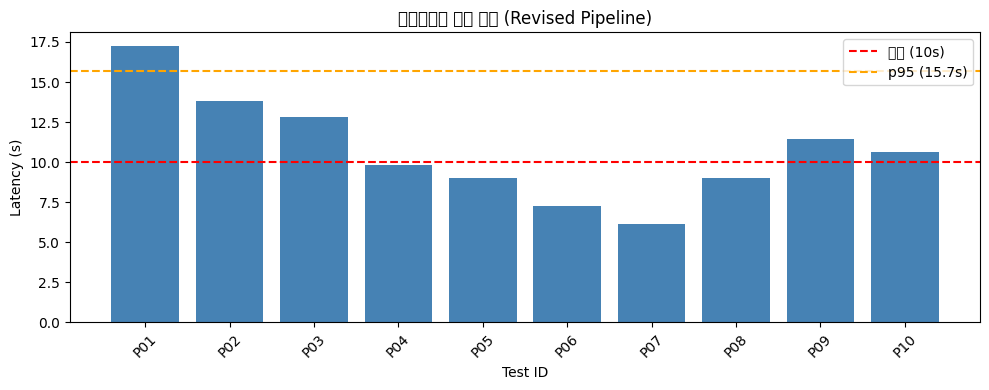

In [12]:
latency_vals = pipeline_df[pipeline_df['status'] == 'OK']['latency_s'].dropna()

if len(latency_vals) > 0:
    p50  = np.percentile(latency_vals, 50)
    p95  = np.percentile(latency_vals, 95)
    pmax = latency_vals.max()

    print("--- 응답 시간 분포 ---")
    print(f"  p50 : {p50:.2f}s")
    print(f"  p95 : {p95:.2f}s  <- 목표: 10초 이내")
    print(f"  max : {pmax:.2f}s")
    print()
    print("O p95 기준 통과" if p95 <= 10 else "X p95 기준 초과 -> 모델/top_k 조정 필요")

    # 시각화
    plt.figure(figsize=(10, 4))
    ok_df = pipeline_df[pipeline_df['status'] == 'OK']
    plt.bar(ok_df['test_id'], ok_df['latency_s'], color='steelblue')
    plt.axhline(y=10,  color='red',    linestyle='--', label='목표 (10s)')
    plt.axhline(y=p95, color='orange', linestyle='--', label=f'p95 ({p95:.1f}s)')
    plt.xlabel('Test ID')
    plt.ylabel('Latency (s)')
    plt.title('파이프라인 응답 시간 (Revised Pipeline)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

### 9. Faithfulness 및 톤앤매너 검증


In [13]:
faith_df = pipeline_df[pipeline_df['Faithfulness'].notna()]
tone_df  = pipeline_df[pipeline_df['Tone_OK'].notna()]

print("=== Faithfulness (근거 기반 답변 여부) ===")
if len(faith_df) > 0:
    faith_rate = faith_df['Faithfulness'].mean()
    print(f"  근거 있음 비율: {faith_rate:.1%}")
    print(f"  (기준: 검색 문서와 단어 3개 이상 겹침)")
else:
    print("  측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

print()
print("=== 톤앤매너 (확답 표현 없는지) ===")
if len(tone_df) > 0:
    tone_rate = tone_df['Tone_OK'].mean()
    print(f"  확답 표현 없음 비율: {tone_rate:.1%}")
    print(f"  (기준: DEFINITIVE_PATTERNS 미포함)")
else:
    print("  측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

=== Faithfulness (근거 기반 답변 여부) ===
  근거 있음 비율: 80.0%
  (기준: 검색 문서와 단어 3개 이상 겹침)

=== 톤앤매너 (확답 표현 없는지) ===
  확답 표현 없음 비율: 100.0%
  (기준: DEFINITIVE_PATTERNS 미포함)


### 10. Citation 정확도 검증 [신규]


In [14]:
citation_df = pipeline_df[pipeline_df['citation_accuracy'].notna()]

print("=== Citation URL 정확도 ===")
if len(citation_df) > 0:
    avg_accuracy = citation_df['citation_accuracy'].mean()
    total_citations = citation_df['citation_count'].sum()
    print(f"  평균 Citation URL 정확도: {avg_accuracy:.1%}")
    print(f"  검증 대상 테스트 수: {len(citation_df)}")
    print(f"  총 Citation 수: {int(total_citations)}")
    print()

    # 테스트별 상세
    for _, row in citation_df.iterrows():
        status = "O" if row['citation_accuracy'] == 1.0 else "X"
        print(f"  [{row['test_id']}] {status} accuracy={row['citation_accuracy']:.1%} "
              f"(citations: {int(row['citation_count'])})")
else:
    print("  측정 가능한 케이스 없음 (Qdrant 연결 후 재실행)")

=== Citation URL 정확도 ===
  평균 Citation URL 정확도: 100.0%
  검증 대상 테스트 수: 10
  총 Citation 수: 43

  [P01] O accuracy=100.0% (citations: 4)
  [P02] O accuracy=100.0% (citations: 4)
  [P03] O accuracy=100.0% (citations: 5)
  [P04] O accuracy=100.0% (citations: 4)
  [P05] O accuracy=100.0% (citations: 2)
  [P06] O accuracy=100.0% (citations: 5)
  [P07] O accuracy=100.0% (citations: 5)
  [P08] O accuracy=100.0% (citations: 4)
  [P09] O accuracy=100.0% (citations: 5)
  [P10] O accuracy=100.0% (citations: 5)


### 11. 최종 결과 요약


In [15]:
print('=' * 100)
print('Phase 1 단위 테스트')
print('=' * 100)
for df, name in [
    (a_df, "Group A - check_sensitive_info (정규식)"),
    (b_df, "Group B - intent_understanding (LLM+JSON)"),
    (c_df, "Group C - query_summary (LLM+JSON) [신규]"),
    (d_df, "Group D - resolve_citations (결정론적) [신규]"),
    (e_df, "Group E - expression_revision (정규식+LLM)"),
]:
    ok = (df['status'] == 'PASS').sum()
    total = len(df)
    print(f"  {name}: {ok}/{total} ({ok/total*100:.0f}%)")

print()
print('=' * 100)
print('Phase 2 통합 테스트')
print('=' * 100)
for group in pipeline_df['group'].unique():
    g = pipeline_df[pipeline_df['group'] == group]
    ok = (g['status'] == 'OK').sum()
    total = len(g)
    print(f"  {group}: {ok}/{total} ({ok/total*100:.0f}%)")

print()
print('=' * 100)
print('핵심 성능 지표')
print('=' * 100)

faith_rate = faith_df['Faithfulness'].mean() if len(faith_df) > 0 else None
tone_rate  = tone_df['Tone_OK'].mean() if len(tone_df) > 0 else None
cite_rate  = citation_df['citation_accuracy'].mean() if len(citation_df) > 0 else None

summary = {
    'Recall@3 (평균)':     f"{valid['Recall@3'].mean():.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'MRR (평균)':          f"{valid['MRR'].mean():.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'Hit Rate':            f"{hit_rate:.3f}" if len(valid) > 0 else "N/A (Qdrant 필요)",
    'p95 Latency':         f"{p95:.2f}s" if len(latency_vals) > 0 else "N/A (Qdrant 필요)",
    'Faithfulness':        f"{faith_rate:.1%}" if faith_rate is not None else "N/A (Qdrant 필요)",
    '톤앤매너 준수율':      f"{tone_rate:.1%}" if tone_rate is not None else "N/A (Qdrant 필요)",
    'Citation Accuracy':   f"{cite_rate:.1%}" if cite_rate is not None else "N/A (Qdrant 필요)",
}

for metric_name, metric_val in summary.items():
    print(f"  {metric_name:22s}: {metric_val}")

Phase 1 단위 테스트
  Group A - check_sensitive_info (정규식): 10/10 (100%)
  Group B - intent_understanding (LLM+JSON): 4/6 (67%)
  Group C - query_summary (LLM+JSON) [신규]: 6/6 (100%)
  Group D - resolve_citations (결정론적) [신규]: 13/13 (100%)
  Group E - expression_revision (정규식+LLM): 8/8 (100%)

Phase 2 통합 테스트
  정상통과: 4/4 (100%)
  할루시네이션방지: 2/2 (100%)
  유사도차단: 2/2 (100%)
  Citation검증: 2/2 (100%)

핵심 성능 지표
  Recall@3 (평균)         : 1.000
  MRR (평균)              : 0.857
  Hit Rate              : 1.000
  p95 Latency           : 15.70s
  Faithfulness          : 80.0%
  톤앤매너 준수율              : 100.0%
  Citation Accuracy     : 100.0%
